# GNN — GINConv Baseline for Glaze Property Prediction

Predict surface finish (9-class), transparency (4-class), and color family (9-class) from UMF vectors using a 3-layer GIN with domain-informed adjacency.

**Architecture:** GINConv(7→128→128→128) + GlobalMeanPool||GlobalMaxPool → 3 heads
**Adjacency:** Fixed by ceramic role (former↔stabilizer, former↔flux, stabilizer↔flux)
**Comparison:** vs XGBoost baseline (from notebook 01)

## 0. Install dependencies (run once)

In [1]:
# Install PyTorch + PyG + xgboost for baseline comparison
# NOTE: restart runtime after install if running on Colab
import sys, subprocess, os, warnings

try:
    import torch
    print(f'PyTorch {torch.__version__} (CUDA: {torch.cuda.is_available()})')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch', '--index-url', 'https://download.pytorch.org/whl/cu121'])

try:
    import torch_geometric
    print(f'PyG {torch_geometric.__version__}')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch-geometric'])

try:
    import xgboost
    print(f'XGBoost {xgboost.__version__}')
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', 'scikit-learn', 'pandas', 'seaborn'])

warnings.filterwarnings('ignore')
print('Done')

PyTorch 2.9.1+gitff65f5b (CUDA: True)


/opt/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyG 2.8.0
XGBoost 3.2.0
Done


## 1. Imports

In [2]:
import urllib.request
import urllib.error
import json
import os
import subprocess
import time
import warnings
from collections import Counter
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torch_geometric.nn import GINConv, global_mean_pool, global_max_pool
from torch_geometric.data import Data, Batch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, log_loss, confusion_matrix, classification_report
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


---
## 2. Download GlazyBench data from Hugging Face

In [3]:
DATA_DIR = 'data/property_prediction'
assert os.path.exists(DATA_DIR), f'Data not found at {DATA_DIR}. Upload the GlazyBench/property_prediction folder to data/'

def load_json(path):
    with open(os.path.join(DATA_DIR, path)) as f:
        return json.load(f)

train_recipes = load_json('train/recipes.json')
train_targets = load_json('train/targets.json')
test_recipes = load_json('test/recipes.json')
test_targets = load_json('test/targets.json')

print(f'Train recipes: {len(train_recipes)}  targets: {len(train_targets)}')
print(f'Test recipes:  {len(test_recipes)}  targets: {len(test_targets)}')

Train recipes: 16781  targets: 16781
Test recipes:  4903  targets: 4903


In [4]:
def merge_data(recipes, targets):
    target_map = {t['id']: t for t in targets}
    rows = []
    for r in recipes:
        t = target_map.get(r['id'])
        if t is None:
            continue
        row = {'id': r['id']}
        for ox, val in (r.get('umf') or {}).items():
            row[f'umf_{ox}'] = val
        row['cone_min'] = r.get('cone_min')
        row['cone_max'] = r.get('cone_max')
        row['atmosphere'] = r.get('atmosphere', '')
        row['surface'] = t.get('surface')
        row['transparency'] = t.get('transparency')
        row['color_family'] = t.get('color_family')
        row['umf_oxides'] = list((r.get('umf') or {}).keys())
        row['umf_values'] = list((r.get('umf') or {}).values())
        rows.append(row)
    return pd.DataFrame(rows)

df_train = merge_data(train_recipes, train_targets)
df_test = merge_data(test_recipes, test_targets)

# Filter out null-UMF recipes (empty graphs crash GNN batching)
df_train = df_train[df_train['umf_oxides'].apply(len) > 0].reset_index(drop=True)
df_test = df_test[df_test['umf_oxides'].apply(len) > 0].reset_index(drop=True)

print(f'Train: {df_train.shape}  Test: {df_test.shape}')

Train: (15668, 27)  Test: (4849, 27)


---
## 3. Domain-informed adjacency & node features

### Oxide roles (ceramic chemistry)

| Role | Oxides |
|------|--------|
| Former | SiO₂, B₂O₃ |
| Stabilizer | Al₂O₃, Fe₂O₃ |
| Flux | Na₂O, K₂O, CaO, MgO, ZnO, Li₂O, PbO |
| Colorant | Fe₂O₃ (also stabilizer), CuO, CoO, Cr₂O₃, MnO₂ |

**Edges:** every node in role A connects to every node in role B.
- Former ⟷ Stabilizer
- Former ⟷ Flux
- Stabilizer ⟷ Flux

### Node features (7-dim)
0. mol% (UMF mole fraction)
1-4. role one-hot [former, stabilizer, flux, colorant]
5. atomic_mass / 100
6. presence (1.0 if oxide present in recipe)

In [5]:
# Oxide properties
OXIDE_PROPS = {
    'SiO2':  {'role': 'former',     'mass': 60.08},
    'B2O3':  {'role': 'former',     'mass': 69.62},
    'Al2O3': {'role': 'stabilizer', 'mass': 101.96},
    'Fe2O3': {'role': 'colorant',   'mass': 159.69},
    'Na2O':  {'role': 'flux',       'mass': 61.98},
    'K2O':   {'role': 'flux',       'mass': 94.20},
    'CaO':   {'role': 'flux',       'mass': 56.08},
    'MgO':   {'role': 'flux',       'mass': 40.30},
    'ZnO':   {'role': 'flux',       'mass': 81.38},
    'Li2O':  {'role': 'flux',       'mass': 29.88},
    'PbO':   {'role': 'flux',       'mass': 223.20},
    'CuO':   {'role': 'colorant',   'mass': 79.55},
    'CoO':   {'role': 'colorant',   'mass': 74.93},
    'Cr2O3': {'role': 'colorant',   'mass': 151.99},
    'MnO2':  {'role': 'colorant',   'mass': 86.94},
    'BaO':   {'role': 'flux',       'mass': 153.33},
    'P2O5':  {'role': 'former',     'mass': 141.94},
    'SnO2':  {'role': 'stabilizer', 'mass': 150.71},
    'SrO':   {'role': 'flux',       'mass': 103.62},
    'TiO2':  {'role': 'colorant',   'mass': 79.87},
    'ZrO2':  {'role': 'stabilizer', 'mass': 123.22},
}

ROLE_TO_IDX = {'former': 0, 'stabilizer': 1, 'flux': 2, 'colorant': 3}

# Domain adjacency rules
DOMAIN_EDGE_RULES = [
    ('former', 'stabilizer'),
    ('former', 'flux'),
    ('stabilizer', 'flux'),
]

ALL_OXIDES = sorted(OXIDE_PROPS.keys())
print(f'Registered oxides ({len(ALL_OXIDES)}): {ALL_OXIDES}')

Registered oxides (21): ['Al2O3', 'B2O3', 'BaO', 'CaO', 'CoO', 'Cr2O3', 'CuO', 'Fe2O3', 'K2O', 'Li2O', 'MgO', 'MnO2', 'Na2O', 'P2O5', 'PbO', 'SiO2', 'SnO2', 'SrO', 'TiO2', 'ZnO', 'ZrO2']


In [6]:
def build_node_features(oxide_names, oxide_values):
    """Build (N, 7) node feature tensor for a recipe."""
    n = len(oxide_names)
    feats = torch.zeros(n, 7, dtype=torch.float)
    for i, (name, val) in enumerate(zip(oxide_names, oxide_values)):
        props = OXIDE_PROPS.get(name, {'role': 'flux', 'mass': 60.0})
        role_idx = ROLE_TO_IDX.get(props['role'], 2)
        feats[i, 0] = val  # mol%
        feats[i, 1 + role_idx] = 1.0  # role one-hot
        feats[i, 5] = props['mass'] / 100.0  # atomic mass / 100
        feats[i, 6] = 1.0  # presence
    return feats


def build_domain_edge_index(oxide_names):
    """Build (2, E) edge_index using domain-informed rules.
    
    Edges: every former connects to every stabilizer,
           every former connects to every flux,
           every stabilizer connects to every flux.
    """
    roles = []
    for name in oxide_names:
        props = OXIDE_PROPS.get(name, {'role': 'flux'})
        roles.append(props['role'])
    
    edges = []
    n = len(oxide_names)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            ri, rj = roles[i], roles[j]
            for ra, rb in DOMAIN_EDGE_RULES:
                if (ri == ra and rj == rb) or (ri == rb and rj == ra):
                    edges.append([i, j])
                    break
    
    if len(edges) == 0:
        # fallback: self-loop only (shouldn't happen with >1 oxide)
        edges = [[i, i] for i in range(n)]
    
    return torch.tensor(edges, dtype=torch.long).t().contiguous()


def recipe_to_pyg_data(oxide_names, oxide_values, labels_dict):
    """Convert one recipe to PyG Data object."""
    x = build_node_features(oxide_names, oxide_values)
    edge_index = build_domain_edge_index(oxide_names)
    data = Data(x=x, edge_index=edge_index)
    for head, label in labels_dict.items():
        if label is not None:
            data[head] = torch.tensor([label], dtype=torch.long)
    return data


# Test on a recipe
sample = df_train.iloc[0]
data = recipe_to_pyg_data(sample['umf_oxides'], sample['umf_values'], {})
print(f'Sample: {sample["id"]}')
print(f'  Nodes: {data.num_nodes}  Edges: {data.num_edges}')
print(f'  Node features: {data.x.shape}')
print(f'  Edge index: {data.edge_index.shape}')

Sample: 10009
  Nodes: 8  Edges: 22
  Node features: torch.Size([8, 7])
  Edge index: torch.Size([2, 22])


---
## 4. Prepare datasets

Build PyG Data objects per head for labeled recipes. Store as arrays of `Data` objects.

In [7]:
TARGET_HEADS = ['surface', 'transparency', 'color_family']

head_encoders = {}
head_datasets = {}  # head -> {'train': [Data, ...], 'test': [Data, ...]}

for head in TARGET_HEADS:
    le = LabelEncoder()
    
    # Build train data
    train_mask = df_train[head].notna()
    train_labels = le.fit_transform(df_train.loc[train_mask, head])
    train_set = []
    train_rows = df_train[train_mask]
    for _, row in train_rows.iterrows():
        data = recipe_to_pyg_data(row['umf_oxides'], row['umf_values'], {head: train_labels[len(train_set)]})
        train_set.append(data)
    
    # Build test data
    test_mask = df_test[head].notna()
    test_labels = le.transform(df_test.loc[test_mask, head])
    test_set = []
    test_rows = df_test[test_mask]
    for _, row in test_rows.iterrows():
        data = recipe_to_pyg_data(row['umf_oxides'], row['umf_values'], {head: test_labels[len(test_set)]})
        test_set.append(data)
    
    head_encoders[head] = le
    head_datasets[head] = {
        'train': train_set,
        'test': test_set,
        'classes': le.classes_,
        'n_classes': len(le.classes_),
    }
    
    print(f'{head:15s}: train={len(train_set):5d}  test={len(test_set):4d}  classes={list(le.classes_)}')

surface        : train= 9367  test=3728  classes=['Dry Matte', 'Glossy', 'Matte', 'Satin', 'Satin-matte', 'Semi-glossy', 'Semi-matte', 'Smooth Matte', 'Stony Matte']
transparency   : train= 9013  test=3320  classes=['Opaque', 'Semi-opaque', 'Translucent', 'Transparent']
color_family   : train=15668  test=4849  classes=['Black', 'Blue', 'Gray', 'Green', 'Orange', 'Purple', 'Red', 'White', 'Yellow']


---
## 5. GlazeGNN model

Exactly as specified in `gnn/SPECIFICATION.md`:
- 3× GINConv (7→128, 128→128, 128→128)
- BatchNorm + ReLU + Dropout(0.15) after conv1 and conv2
- GlobalMeanPool || GlobalMaxPool → concat(256)
- 3 independent heads (9/4/9 classes with LogSoftmax)

In [8]:
class GlazeGNN(torch.nn.Module):
    def __init__(self, n_classes_surface=9, n_classes_transparency=4, n_classes_color=9):
        super().__init__()
        h = 128
        
        def make_mlp(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(),
                nn.Linear(out_dim, out_dim),
            )
        
        self.conv1 = GINConv(make_mlp(7, h), train_eps=True)
        self.conv2 = GINConv(make_mlp(h, h), train_eps=True)
        self.conv3 = GINConv(make_mlp(h, h), train_eps=True)
        
        self.dropout = nn.Dropout(0.15)
        pooled_dim = h * 2  # mean + max
        
        self.surface_head = nn.Linear(pooled_dim, n_classes_surface)
        self.transparency_head = nn.Linear(pooled_dim, n_classes_transparency)
        self.color_head = nn.Linear(pooled_dim, n_classes_color)
    
    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=-1)
        
        surface = F.log_softmax(self.surface_head(x), dim=-1)
        trans = F.log_softmax(self.transparency_head(x), dim=-1)
        color = F.log_softmax(self.color_head(x), dim=-1)
        
        return surface, trans, color


# Verify model
model = GlazeGNN().to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 90,009


In [9]:
def collate_graphs(graphs):
    """Collate a list of PyG Data objects into a batch."""
    if len(graphs) == 0:
        return None
    return Batch.from_data_list(graphs)


def train_epoch(model, loader, optimizer, head):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        s, t, c = model(batch.x, batch.edge_index, batch.batch)
        
        out_map = {'surface': s, 'transparency': t, 'color_family': c}
        out = out_map[head]
        labels = batch[head]
        
        loss = F.nll_loss(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, head):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        s, t, c = model(batch.x, batch.edge_index, batch.batch)
        
        out_map = {'surface': s, 'transparency': t, 'color_family': c}
        out = out_map[head]
        labels = batch[head]
        
        total_loss += F.nll_loss(out, labels).item() * batch.num_graphs
        preds = out.argmax(dim=-1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    loss = total_loss / len(loader.dataset)
    
    return {
        'accuracy': accuracy_score(all_labels, all_preds),
        'macro_f1': f1_score(all_labels, all_preds, average='macro'),
        'weighted_f1': f1_score(all_labels, all_preds, average='weighted'),
        'loss': loss,
        'preds': all_preds,
        'labels': all_labels,
    }

---
## 6. Train a model per head (5-fold CV)

For fair comparison with the XGBoost baseline, we use the same 5-fold stratified CV setup.

In [10]:
N_FOLDS = 5
N_EPOCHS = 100
BATCH_SIZE = 64
PATIENCE = 10
LR = 1e-3

gnn_cv_results = {}
gnn_loss_curves = {}

for head in TARGET_HEADS:
    print(f'\n{"="*60}')
    print(f'  {head}')
    print(f'{"="*60}')
    
    train_data = head_datasets[head]['train']
    n_classes = head_datasets[head]['n_classes']
    labels_arr = np.array([d[head].item() for d in train_data])
    
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_results = []
    fold_curves = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(train_data)), labels_arr)):
        print(f'\n  --- Fold {fold+1}/{N_FOLDS} ---')
        
        train_fold = [train_data[i] for i in train_idx]
        val_fold = [train_data[i] for i in val_idx]
        
        train_loader = DataLoader(train_fold, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_graphs)
        val_loader = DataLoader(val_fold, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_graphs)
        
        model = GlazeGNN(n_classes_color=n_classes if head == 'color_family' else 9,
                         n_classes_transparency=n_classes if head == 'transparency' else 4,
                         n_classes_surface=n_classes if head == 'surface' else 9).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
        
        best_val_loss = float('inf')
        best_metrics = None
        patience_counter = 0
        val_losses = []
        train_losses = []
        
        for epoch in range(1, N_EPOCHS + 1):
            train_loss = train_epoch(model, train_loader, optimizer, head)
            val_metrics = evaluate(model, val_loader, head)
            train_losses.append(train_loss)
            val_losses.append(val_metrics['loss'])
            
            if val_metrics['loss'] < best_val_loss:
                best_val_loss = val_metrics['loss']
                best_metrics = {k: v for k, v in val_metrics.items() if k != 'preds' and k != 'labels'}
                patience_counter = 0
            else:
                patience_counter += 1
            
            if epoch % 10 == 0 or epoch == 1:
                print(f'    epoch {epoch:3d}  train_loss={train_loss:.4f}  val_loss={val_metrics["loss"]:.4f}  val_acc={val_metrics["accuracy"]:.4f}')
            
            if patience_counter >= PATIENCE:
                print(f'    early stopping at epoch {epoch}')
                break
        
        print(f'    Best: {best_metrics}')
        fold_results.append(best_metrics)
        fold_curves.append({'train': train_losses, 'val': val_losses})
    
    
    gnn_cv_results[head] = fold_results
    gnn_loss_curves[head] = fold_curves
    
    mean_m = {k: np.mean([m[k] for m in fold_results]) for k in fold_results[0]}
    std_m = {k: np.std([m[k] for m in fold_results]) for k in fold_results[0]}
    print(f'\n  {head} CV mean: ' + '  '.join(f'{k}={v:.4f}' for k, v in mean_m.items()))
    print(f'  {head} CV std:  ' + '  '.join(f'{k}={v:.4f}' for k, v in std_m.items()))


  surface

  --- Fold 1/5 ---
    epoch   1  train_loss=1.6375  val_loss=1.6698  val_acc=0.4931
    epoch  10  train_loss=1.5330  val_loss=1.9030  val_acc=0.4893
    epoch  20  train_loss=1.4400  val_loss=2.0924  val_acc=0.3314
    early stopping at epoch 23
    Best: {'accuracy': 0.49306296691568835, 'macro_f1': 0.08621743424461405, 'weighted_f1': 0.3370274738024056, 'loss': 1.640278071833013}

  --- Fold 2/5 ---
    epoch   1  train_loss=1.6405  val_loss=1.6375  val_acc=0.4899
    epoch  10  train_loss=1.5365  val_loss=1.8062  val_acc=0.4904
    epoch  20  train_loss=1.4381  val_loss=1.9463  val_acc=0.2033
    early stopping at epoch 28
    Best: {'accuracy': 0.48665955176093917, 'macro_f1': 0.13566424989323353, 'weighted_f1': 0.3939712989055223, 'loss': 1.5694166171258135}

  --- Fold 3/5 ---
    epoch   1  train_loss=1.6367  val_loss=1.6760  val_acc=0.4901
    epoch  10  train_loss=1.5336  val_loss=1.6831  val_acc=0.4901
    early stopping at epoch 16
    Best: {'accuracy': 0.4922

---
## 7. Cross-validation comparison: GNN vs XGBoost

Run XGBoost baseline in-cell for a fair comparison (same data, same folds).

In [12]:
print(f'{"Head":<15s} {"Model":<10s} {"Accuracy":>10s} {"Macro F1":>10s} {"Wtd F1":>10s} {"Loss":>10s}')
print('-' * 65)

# XGBoost baseline on same folds
xgb_params = {
    'objective': 'multi:softprob',
    'eval_metric': ['mlogloss', 'merror'],
    'learning_rate': 0.1, 'max_depth': 6,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'seed': 42,
}

# Build flat feature matrix for XGBoost (match notebook 01 features)
ALL_OXIDE_COLS = sorted(set(
    c for c in df_train.columns if c.startswith('umf_') and c not in ('umf_oxides', 'umf_values')
) | set(
    c for c in df_test.columns if c.startswith('umf_') and c not in ('umf_oxides', 'umf_values')
))
for col in ALL_OXIDE_COLS:
    if col not in df_train.columns:
        df_train[col] = 0.0
    if col not in df_test.columns:
        df_test[col] = 0.0

# Encode atmosphere and clip cone outliers
for df in [df_train, df_test]:
    df['atmos_oxidation'] = (df['atmosphere'].str.lower().str.contains('oxidation', na=False)).astype(float)
    df['atmos_reduction'] = (df['atmosphere'].str.lower().str.contains('reduction', na=False)).astype(float)
    df['cone_max'] = df['cone_max'].clip(upper=22)

FEAT_COLS = ALL_OXIDE_COLS + ['atmos_oxidation', 'atmos_reduction', 'cone_min', 'cone_max']

xgb_cv_results = {}

for head in TARGET_HEADS:
    train_mask = df_train[head].notna()
    y = df_train.loc[train_mask, head]
    X = df_train.loc[train_mask, FEAT_COLS].fillna(0.0).values.astype(np.float32)
    
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    xgb_folds = []
    
    for train_idx, val_idx in skf.split(X, y_enc):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y_enc[train_idx], y_enc[val_idx]
        
        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dval = xgb.DMatrix(X_val, label=y_val)
        
        m = xgb.train({**xgb_params, 'num_class': len(le.classes_)}, dtrain,
                      num_boost_round=500, evals=[(dval, 'val')],
                      early_stopping_rounds=30, verbose_eval=False)
        
        y_pred = np.argmax(m.predict(dval), axis=1)
        xgb_folds.append({
            'accuracy': accuracy_score(y_val, y_pred),
            'macro_f1': f1_score(y_val, y_pred, average='macro'),
            'weighted_f1': f1_score(y_val, y_pred, average='weighted'),
        })
    
    xgb_cv_results[head] = xgb_folds
    
    gnn_mean = {k: np.mean([m[k] for m in gnn_cv_results[head]]) for k in ['accuracy', 'macro_f1', 'weighted_f1']}
    gnn_std = {k: np.std([m[k] for m in gnn_cv_results[head]]) for k in ['accuracy', 'macro_f1', 'weighted_f1']}
    xgb_mean = {k: np.mean([m[k] for m in xgb_folds]) for k in ['accuracy', 'macro_f1', 'weighted_f1']}
    xgb_std = {k: np.std([m[k] for m in xgb_folds]) for k in ['accuracy', 'macro_f1', 'weighted_f1']}
    
    for model_name, means, stds in [('GNN', gnn_mean, gnn_std), ('XGBoost', xgb_mean, xgb_std)]:
        print(f'{head:<15s} {model_name:<10s}  {means["accuracy"]:.4f}±{stds["accuracy"]:.4f}'
              f'  {means["macro_f1"]:.4f}±{stds["macro_f1"]:.4f}'
              f'  {means["weighted_f1"]:.4f}±{stds["weighted_f1"]:.4f}')
    print()

Head            Model        Accuracy   Macro F1     Wtd F1       Loss
-----------------------------------------------------------------
surface         GNN         0.4917±0.0028  0.0926±0.0219  0.3450±0.0249
surface         XGBoost     0.6214±0.0094  0.4006±0.0201  0.5810±0.0105

transparency    GNN         0.5141±0.0031  0.2833±0.0195  0.4045±0.0150
transparency    XGBoost     0.6602±0.0065  0.5795±0.0116  0.6430±0.0084

color_family    GNN         0.3509±0.0062  0.1238±0.0099  0.2530±0.0102
color_family    XGBoost     0.4152±0.0023  0.2670±0.0068  0.3731±0.0049



---
## 8. GNN loss curves (mean across folds)

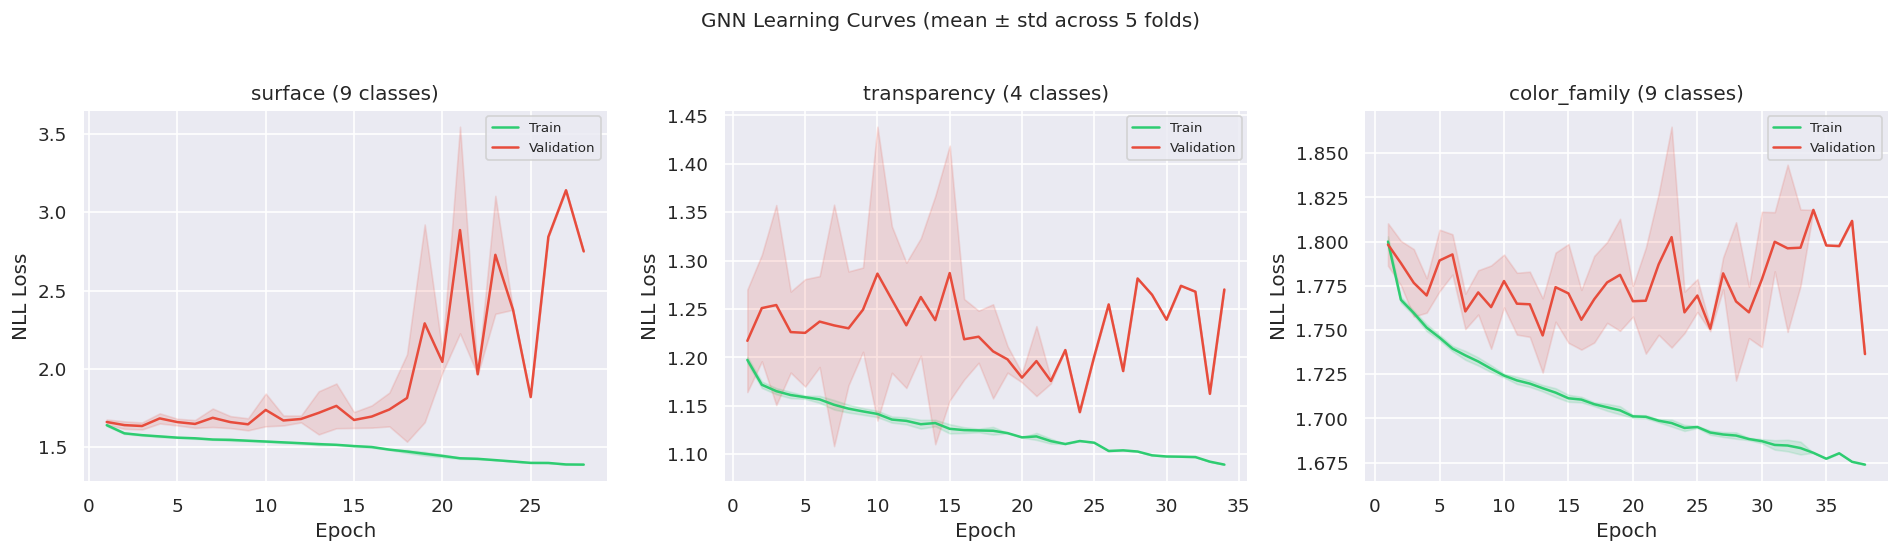

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, head in zip(axes, TARGET_HEADS):
    curves = gnn_loss_curves[head]
    
    max_len = max(len(c['train']) for c in curves)
    train_arr = np.full((N_FOLDS, max_len), np.nan)
    val_arr = np.full((N_FOLDS, max_len), np.nan)
    for i, c in enumerate(curves):
        tlen = len(c['train'])
        train_arr[i, :tlen] = c['train']
        val_arr[i, :tlen] = c['val']
    
    rounds = np.arange(1, max_len + 1)
    ax.plot(rounds, np.nanmean(train_arr, axis=0), label='Train', color='#2ecc71')
    ax.fill_between(rounds, np.nanmean(train_arr, axis=0) - np.nanstd(train_arr, axis=0),
                    np.nanmean(train_arr, axis=0) + np.nanstd(train_arr, axis=0), alpha=0.15, color='#2ecc71')
    ax.plot(rounds, np.nanmean(val_arr, axis=0), label='Validation', color='#e74c3c')
    ax.fill_between(rounds, np.nanmean(val_arr, axis=0) - np.nanstd(val_arr, axis=0),
                    np.nanmean(val_arr, axis=0) + np.nanstd(val_arr, axis=0), alpha=0.15, color='#e74c3c')
    
    ax.set_title(f'{head} ({head_datasets[head]["n_classes"]} classes)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('NLL Loss')
    ax.legend(fontsize=8)

plt.suptitle('GNN Learning Curves (mean ± std across 5 folds)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Final test set evaluation

Train GNN on full training set, evaluate on held-out test. Compare with XGBoost.

In [14]:
print(f'{"Head":<15s} {"Model":<10s} {"Accuracy":>10s} {"Macro F1":>10s} {"Wtd F1":>10s}')
print('-' * 55)

gnn_test_results = {}
xgb_test_results = {}

for head in TARGET_HEADS:
    n_classes = head_datasets[head]['n_classes']
    
    # --- GNN ---
    train_set = head_datasets[head]['train']
    test_set = head_datasets[head]['test']
    
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_graphs)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_graphs)
    
    model = GlazeGNN(n_classes_color=n_classes if head == 'color_family' else 9,
                     n_classes_transparency=n_classes if head == 'transparency' else 4,
                     n_classes_surface=n_classes if head == 'surface' else 9).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
    
    for epoch in range(1, N_EPOCHS + 1):
        train_loss = train_epoch(model, train_loader, optimizer, head)
        if epoch % 20 == 0:
            print(f'  {head} GNN epoch {epoch:3d}  train_loss={train_loss:.4f}')
    
    test_metrics = evaluate(model, test_loader, head)
    gnn_test_results[head] = test_metrics
    
    print(f'{head:<15s} {"GNN":<10s}  {test_metrics["accuracy"]:.4f}  {test_metrics["macro_f1"]:.4f}'
          f'  {test_metrics["weighted_f1"]:.4f}')
    
    # --- XGBoost ---
    train_mask = df_train[head].notna()
    test_mask = df_test[head].notna()
    
    le = LabelEncoder()
    y_train = le.fit_transform(df_train.loc[train_mask, head])
    y_test = le.transform(df_test.loc[test_mask, head])
    X_train = df_train.loc[train_mask, FEAT_COLS].fillna(0.0).values.astype(np.float32)
    X_test = df_test.loc[test_mask, FEAT_COLS].fillna(0.0).values.astype(np.float32)
    
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test)
    
    xgb_model = xgb.train({**xgb_params, 'num_class': len(le.classes_)}, dtrain,
                          num_boost_round=150, verbose_eval=False)
    y_pred = np.argmax(xgb_model.predict(dtest), axis=1)
    
    xgb_test_results[head] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
        'weighted_f1': f1_score(y_test, y_pred, average='weighted'),
    }
    
    print(f'{head:<15s} {"XGBoost":<10s}  {xgb_test_results[head]["accuracy"]:.4f}  {xgb_test_results[head]["macro_f1"]:.4f}'
          f'  {xgb_test_results[head]["weighted_f1"]:.4f}')
    print()

Head            Model        Accuracy   Macro F1     Wtd F1
-------------------------------------------------------
  surface GNN epoch  20  train_loss=1.4035
  surface GNN epoch  40  train_loss=1.3287
  surface GNN epoch  60  train_loss=1.2691
  surface GNN epoch  80  train_loss=1.2268
  surface GNN epoch 100  train_loss=1.1890
surface         GNN         0.2275  0.1224  0.2362
surface         XGBoost     0.5507  0.2718  0.4822

  transparency GNN epoch  20  train_loss=1.1091
  transparency GNN epoch  40  train_loss=1.0749
  transparency GNN epoch  60  train_loss=1.0327
  transparency GNN epoch  80  train_loss=1.0035
  transparency GNN epoch 100  train_loss=0.9845
transparency    GNN         0.4840  0.3369  0.4033
transparency    XGBoost     0.5675  0.4765  0.5268

  color_family GNN epoch  20  train_loss=1.7043
  color_family GNN epoch  40  train_loss=1.6792
  color_family GNN epoch  60  train_loss=1.6581
  color_family GNN epoch  80  train_loss=1.6376
  color_family GNN epoch 100  t

In [15]:
# Summary comparison table
summary = []
for head in TARGET_HEADS:
    g = gnn_test_results[head]
    x = xgb_test_results[head]
    summary.append({
        'head': head,
        'gnn_acc': g['accuracy'], 'xgb_acc': x['accuracy'],
        'acc_delta': g['accuracy'] - x['accuracy'],
        'gnn_f1': g['macro_f1'], 'xgb_f1': x['macro_f1'],
        'f1_delta': g['macro_f1'] - x['macro_f1'],
    })

s = pd.DataFrame(summary)
print(s.to_string(index=False))

print(f'\nAverage accuracy delta (GNN - XGBoost): {s["acc_delta"].mean():+.4f}')
print(f'Average macro F1 delta (GNN - XGBoost):  {s["f1_delta"].mean():+.4f}')

        head  gnn_acc  xgb_acc  acc_delta   gnn_f1   xgb_f1  f1_delta
     surface 0.227468 0.550697  -0.323230 0.122368 0.271758 -0.149390
transparency 0.484036 0.567470  -0.083434 0.336879 0.476536 -0.139658
color_family 0.273046 0.343576  -0.070530 0.093773 0.209609 -0.115836

Average accuracy delta (GNN - XGBoost): -0.1591
Average macro F1 delta (GNN - XGBoost):  -0.1350


---
## 10. Test set confusion matrices (GNN)

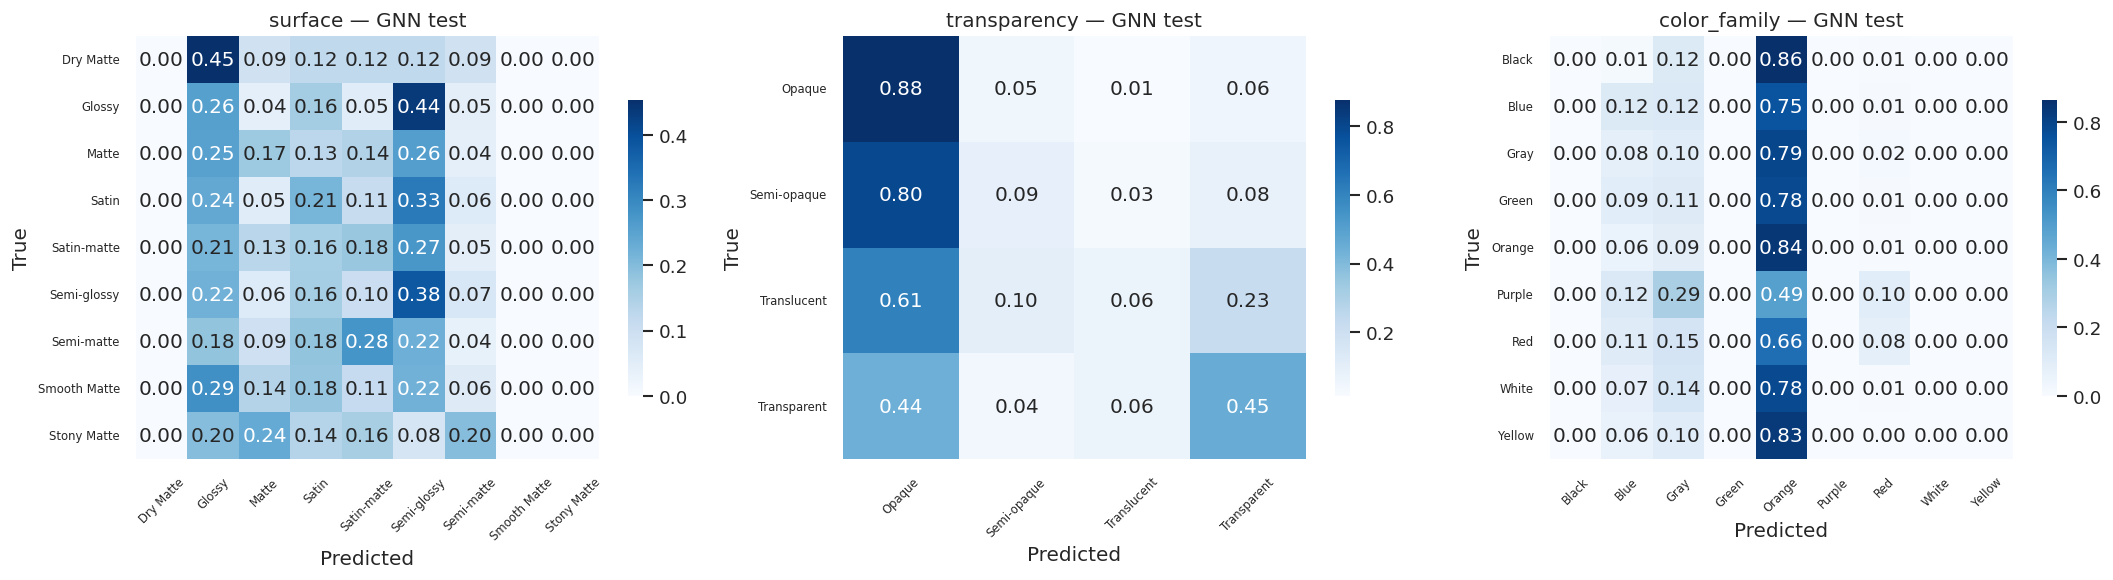

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, head in zip(axes, TARGET_HEADS):
    classes = head_datasets[head]['classes']
    labels = gnn_test_results[head]['labels']
    preds = gnn_test_results[head]['preds']
    
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax, cbar_kws={'shrink': 0.7})
    ax.set_title(f'{head} — GNN test')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.show()

In [17]:
# Summary

print('Test set results:')
print()
print(f'{"Head":<15s} {"GNN Acc":>10s} {"GNN F1":>10s} {"XGB Acc":>10s} {"XGB F1":>10s} {"Δ Acc":>8s} {"Δ F1":>8s}')
print('-' * 75)
for head in TARGET_HEADS:
    g = gnn_test_results[head]
    x = xgb_test_results[head]
    acc_d = g['accuracy'] - x['accuracy']
    f1_d = g['macro_f1'] - x['macro_f1']
    print(f'{head:<15s}  {g["accuracy"]:.4f}  {g["macro_f1"]:.4f}  {x["accuracy"]:.4f}  {x["macro_f1"]:.4f}  {acc_d:+.4f}  {f1_d:+.4f}')
print()
avg_g = {k: np.mean([gnn_test_results[h][k] for h in TARGET_HEADS]) for k in ['accuracy', 'macro_f1']}
avg_x = {k: np.mean([xgb_test_results[h][k] for h in TARGET_HEADS]) for k in ['accuracy', 'macro_f1']}
print(f'{"Average":<15s}  {avg_g["accuracy"]:.4f}  {avg_g["macro_f1"]:.4f}  {avg_x["accuracy"]:.4f}  {avg_x["macro_f1"]:.4f}  {avg_g["accuracy"]-avg_x["accuracy"]:+.4f}  {avg_g["macro_f1"]-avg_x["macro_f1"]:+.4f}')
print()
if avg_g['macro_f1'] - avg_x['macro_f1'] >= 0.03:
    print('GNN beats XGBoost by >=3% macro F1 -- target met!')
else:
    print(f'GNN delta: {avg_g["macro_f1"] - avg_x["macro_f1"]:+.4f} macro F1 (target: +0.03)')


Test set results:

Head               GNN Acc     GNN F1    XGB Acc     XGB F1    Δ Acc     Δ F1
---------------------------------------------------------------------------
surface          0.2275  0.1224  0.5507  0.2718  -0.3232  -0.1494
transparency     0.4840  0.3369  0.5675  0.4765  -0.0834  -0.1397
color_family     0.2730  0.0938  0.3436  0.2096  -0.0705  -0.1158

Average          0.3282  0.1843  0.4872  0.3193  -0.1591  -0.1350

GNN delta: -0.1350 macro F1 (target: +0.03)
